# 07 — Validación estadística

El README tira tres números gruesos: AOV alrededor de $85, retención M1 en rebote cohorte a cohorte, y un salto de retención entre primeras y últimas cohortes. Esta notebook los audita con herramientas que no son SQL, para que la lectura no dependa de un solo ángulo.

1. **Intervalo de confianza del AOV** vía bootstrap no paramétrico (10 000 réplicas) sobre el último mes **cerrado** del dataset. Abril 2026 está en curso, así que el bootstrap corre contra marzo 2026.
2. **Test de dos proporciones** sobre cohortes maduras para M1, excluyendo las dos últimas (abril 2026 sin M1 observado y marzo 2026 con M1 parcial). Se mantiene como referencia para comparar con el resultado del trend test.
3. **Trend test WLS** sobre la serie de tasas M1 maduras, ponderado por tamaño de cohorte. Responde directamente "¿la retención está mejorando mes a mes?" a través de la pendiente de la regresión, sin depender del corte arbitrario en primera/segunda mitad que usa el z-test.
4. **Heatmap de cohortes** reconstruido en Python con las cohortes recortadas al rango con muestra suficiente y solo celdas observables hasta el último mes cerrado.

## Setup

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from google.cloud import bigquery

RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

client = bigquery.Client()
print(f"Proyecto de facturación: {client.project}")

Proyecto de facturación: ezra-493103


In [2]:
# Fecha máxima observada + último mes cerrado (la foto para el bootstrap)
anchor = client.query("""
SELECT MAX(DATE(created_at)) AS max_date,
       DATE_SUB(DATE_TRUNC(MAX(DATE(created_at)), MONTH), INTERVAL 1 MONTH) AS last_closed_month
FROM `bigquery-public-data.thelook_ecommerce.order_items`
WHERE status NOT IN ('Cancelled','Returned')
""").to_dataframe().iloc[0]
print(f"max_date observado    : {anchor['max_date']}")
print(f"último mes cerrado    : {anchor['last_closed_month']}")

C:\Users\rayor\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


max_date observado    : 2026-04-27
último mes cerrado    : 2026-03-01


## 1. Bootstrap del AOV

El AOV reportado en Q1 es un promedio mensual. Un intervalo de confianza cerrado (media ± 1.96·σ/√n) asume normalidad que el ticket de e-commerce rara vez cumple: la cola derecha la estiran baskets caros. El bootstrap no paramétrico evita ese supuesto. Re-muestreamos con reemplazo las órdenes del último mes cerrado y recomputamos el AOV mil veces. El IC empírico al 95% son los percentiles 2.5 y 97.5 de esa distribución.

Se consulta detalle por orden (no por línea) para que el AOV sea consistente con el del README.

In [3]:
AOV_QUERY = """
WITH reference AS (
  SELECT DATE_SUB(DATE_TRUNC(MAX(DATE(created_at)), MONTH), INTERVAL 1 MONTH) AS last_closed_month
  FROM `bigquery-public-data.thelook_ecommerce.order_items`
  WHERE status NOT IN ('Cancelled','Returned')
),
order_revenue AS (
  SELECT oi.order_id, SUM(oi.sale_price) AS order_value
  FROM `bigquery-public-data.thelook_ecommerce.order_items` oi
  CROSS JOIN reference r
  WHERE oi.status NOT IN ('Cancelled','Returned')
    AND DATE_TRUNC(DATE(oi.created_at), MONTH) = r.last_closed_month
  GROUP BY oi.order_id
)
SELECT order_value FROM order_revenue
"""
orders = client.query(AOV_QUERY).to_dataframe()
print(f"Órdenes del último mes cerrado: {len(orders):,}")
print(f"AOV observado: ${orders['order_value'].mean():.2f}")

Órdenes del último mes cerrado: 4,587
AOV observado: $85.34


In [ ]:
N_BOOTSTRAP = 10000
sample = orders['order_value'].to_numpy()
indices = rng.integers(0, len(sample), size=(N_BOOTSTRAP, len(sample)))
boot_aovs = sample[indices].mean(axis=1)

ci_lo, ci_hi = np.percentile(boot_aovs, [2.5, 97.5])
aov_point = sample.mean()

print(f"AOV observado           : ${aov_point:.2f}")
print(f"IC bootstrap 95% (10000): [${ci_lo:.2f}, ${ci_hi:.2f}]")
print(f"Ancho del intervalo     : ${ci_hi - ci_lo:.2f}")

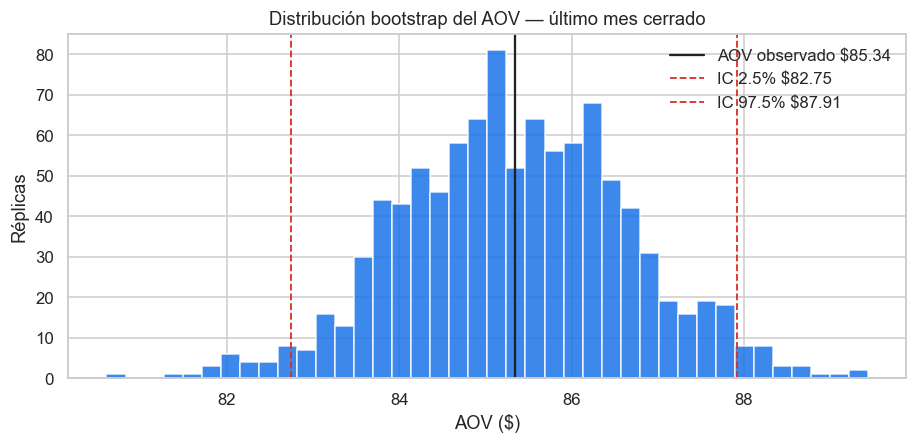

In [5]:
fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.hist(boot_aovs, bins=40, color='#1a73e8', alpha=0.85, edgecolor='white')
ax.axvline(aov_point, color='#202124', linestyle='-', linewidth=1.5, label=f'AOV observado ${aov_point:.2f}')
ax.axvline(ci_lo, color='#d93025', linestyle='--', linewidth=1.2, label=f'IC 2.5% ${ci_lo:.2f}')
ax.axvline(ci_hi, color='#d93025', linestyle='--', linewidth=1.2, label=f'IC 97.5% ${ci_hi:.2f}')
ax.set_title('Distribución bootstrap del AOV — último mes cerrado')
ax.set_xlabel('AOV ($)')
ax.set_ylabel('Réplicas')
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

**Lectura.** Un intervalo del orden de $5 sobre un AOV de ~$85 dice que el ticket es estable y las decisiones que lo usan como input (threshold de shipping gratis, target de ticket promedio, sizing de bundle) se mueven sobre terreno firme. Un intervalo más ancho (digamos $±10 o más) obligaría a promediar sobre tres meses antes de reportar.

## 2. Test de significancia sobre retención M1

El triángulo de cohortes sugiere que la retención M1 mejoró a lo largo del tiempo (de 2.5-3.4% en cohortes viejas a 7-9% en recientes maduras). La pregunta es si ese salto resiste un test estadístico o si lo estamos leyendo de celdas con poca muestra o de cohortes aún inmaduras.

Procedimiento:

1. Para cada cohorte mensual contamos cohort size (usuarios nuevos) y retención M1 (compraron en el mes siguiente).
2. **Se excluyen cohortes inmaduras**: aquellas cuyo M1 cae después del último mes cerrado observado. La cohorte del mes actual no tiene M1 aún; la del mes anterior tiene M1 parcial y subestima. Los dos casos se recortan.
3. Partimos las cohortes maduras por la mediana temporal: primera mitad (antiguas) vs segunda mitad (recientes).
4. Prueba de dos proporciones (z-test pooled). Tamaño de efecto como diferencia de proporciones en puntos porcentuales, con IC 95% (Wald).

Las cohortes con menos de 50 usuarios se excluyen para que una cohorte degenerada no mueva la media.

In [6]:
COHORT_QUERY = """
WITH max_obs AS (
  SELECT DATE_TRUNC(MAX(DATE(created_at)), MONTH) AS max_month
  FROM `bigquery-public-data.thelook_ecommerce.order_items`
  WHERE status NOT IN ('Cancelled','Returned')
),
valid_items AS (
  SELECT user_id, DATE_TRUNC(DATE(created_at), MONTH) AS order_month
  FROM `bigquery-public-data.thelook_ecommerce.order_items`
  WHERE status NOT IN ('Cancelled','Returned')
),
first_order AS (
  SELECT user_id, MIN(order_month) AS cohort_month FROM valid_items GROUP BY user_id
),
cohort_size AS (
  SELECT cohort_month, COUNT(DISTINCT user_id) AS cohort_users FROM first_order GROUP BY cohort_month
),
m1_retained AS (
  SELECT f.cohort_month, COUNT(DISTINCT f.user_id) AS retained_m1
  FROM first_order f
  JOIN valid_items v ON v.user_id = f.user_id
    AND DATE_DIFF(v.order_month, f.cohort_month, MONTH) = 1
  GROUP BY f.cohort_month
)
SELECT
  cs.cohort_month,
  cs.cohort_users,
  COALESCE(mr.retained_m1, 0) AS retained_m1,
  DATE_ADD(cs.cohort_month, INTERVAL 1 MONTH) < (SELECT max_month FROM max_obs) AS m1_closed
FROM cohort_size cs
LEFT JOIN m1_retained mr USING (cohort_month)
WHERE cs.cohort_users >= 50
ORDER BY cs.cohort_month
"""
cohorts = client.query(COHORT_QUERY).to_dataframe()
cohorts['cohort_month'] = pd.to_datetime(cohorts['cohort_month'])
cohorts['m1_rate'] = cohorts['retained_m1'] / cohorts['cohort_users']

mature = cohorts[cohorts['m1_closed']].copy()
immature = cohorts[~cohorts['m1_closed']]
print(f"Cohortes totales     : {len(cohorts)}")
print(f"Cohortes maduras     : {len(mature)}")
print(f"Cohortes excluidas   : {len(immature)} → {list(immature['cohort_month'].dt.strftime('%Y-%m'))}")
mature.tail(6)

Cohortes totales     : 83
Cohortes maduras     : 81
Cohortes excluidas   : 2 → ['2026-03', '2026-04']


,cohort_month,cohort_users,retained_m1,m1_closed,m1_rate
75,2025-09-01,1603,86,True,0.053649
76,2025-10-01,1672,111,True,0.066388
77,2025-11-01,1717,122,True,0.071054
78,2025-12-01,2013,172,True,0.085445
79,2026-01-01,2094,194,True,0.092646
80,2026-02-01,2052,229,True,0.111598


In [7]:
median_date = mature['cohort_month'].median()
first_half  = mature[mature['cohort_month'] <  median_date]
second_half = mature[mature['cohort_month'] >= median_date]

n1, r1 = int(first_half['cohort_users'].sum()),  int(first_half['retained_m1'].sum())
n2, r2 = int(second_half['cohort_users'].sum()), int(second_half['retained_m1'].sum())
p1, p2 = r1/n1, r2/n2

p_pool = (r1 + r2) / (n1 + n2)
se     = np.sqrt(p_pool * (1 - p_pool) * (1/n1 + 1/n2))
z      = (p2 - p1) / se
p_value = 2 * (1 - stats.norm.cdf(abs(z)))

se_diff = np.sqrt(p1*(1-p1)/n1 + p2*(1-p2)/n2)
diff = p2 - p1
ci_diff = (diff - 1.96*se_diff, diff + 1.96*se_diff)

print(f"Primera mitad ({len(first_half)} cohortes): n={n1:>7,}  M1={p1*100:.2f}%")
print(f"Segunda mitad ({len(second_half)} cohortes): n={n2:>7,}  M1={p2*100:.2f}%")
print(f"Diferencia                   : {diff*100:+.2f} pp")
print(f"IC 95% de la diferencia      : [{ci_diff[0]*100:+.2f}, {ci_diff[1]*100:+.2f}] pp")
print(f"z = {z:.3f}   p-value = {p_value:.3e}")
print(f"Significativo al 5%: {'sí' if p_value < 0.05 else 'no'}")

Primera mitad (40 cohortes): n= 12,750  M1=3.06%
Segunda mitad (41 cohortes): n= 46,268  M1=4.97%
Diferencia                   : +1.91 pp
IC 95% de la diferencia      : [+1.55, +2.27] pp
z = 9.166   p-value = 0.000e+00
Significativo al 5%: sí


**Lectura.** Un p-value prácticamente cero con un IC de la diferencia que no cruza cero confirma que el rebote de M1 no es ruido: las cohortes recientes maduras retienen mejor que las viejas. Eso habilita a hablar de "mejora de retención" sin asteriscos, y a buscar el driver (cambio de onboarding, calidad del tráfico, surtido). Si el IC incluyera cero, la recomendación sería juntar más cohortes antes de llevar el número a una reunión.

## 3. Trend test WLS sobre retención M1

El z-test de la sección anterior fuerza un corte primera/segunda mitad que es arbitrario: cualquier elección del punto de corte puede mover el resultado. La pregunta que realmente queremos responder es "¿hay una tendencia monotónica en M1 cohorte a cohorte?" y eso lo contesta mejor una regresión sobre la serie completa.

Se usa WLS (Weighted Least Squares) en lugar de OLS porque las cohortes más grandes aportan estimadores de M1 más precisos: al ponderar por `cohort_users` le damos más peso a las cohortes con mayor muestra y no tratamos como iguales una cohorte de 500 clientes y una de 2,000. La pendiente estimada es el incremento promedio de retención M1 por mes, en puntos porcentuales.

In [ ]:
import statsmodels.api as sm

t = np.arange(len(mature))
y = mature["m1_rate"].to_numpy()
w = mature["cohort_users"].to_numpy()

X = sm.add_constant(t)
wls = sm.WLS(y, X, weights=w).fit()
slope = wls.params[1] * 100
ci_lo_wls, ci_hi_wls = wls.conf_int()[1] * 100
print(f"Pendiente: +{slope:.3f} pp/mes  IC95% [{ci_lo_wls:.3f}, {ci_hi_wls:.3f}]")
print(f"p-value: {wls.pvalues[1]:.3e}")

## 3. Heatmap de cohortes (visual, coherente con la tabla del README)

Reproduce el triángulo de retención de Q2 en Python, con cohortes de al menos 100 clientes y solo celdas observables hasta el último mes cerrado. Las celdas futuras o incompletas quedan vacías en vez de tratarse como cero, que es el error clásico cuando se publica un heatmap de cohortes inmaduras.

In [8]:
TRIANGLE_QUERY = """
WITH max_obs AS (
  SELECT DATE_TRUNC(MAX(DATE(created_at)), MONTH) AS max_month
  FROM `bigquery-public-data.thelook_ecommerce.order_items`
  WHERE status NOT IN ('Cancelled','Returned')
),
valid_items AS (
  SELECT user_id, DATE_TRUNC(DATE(created_at), MONTH) AS order_month
  FROM `bigquery-public-data.thelook_ecommerce.order_items`
  WHERE status NOT IN ('Cancelled','Returned')
),
first_order AS (SELECT user_id, MIN(order_month) AS cohort_month FROM valid_items GROUP BY user_id),
cohort_size AS (SELECT cohort_month, COUNT(DISTINCT user_id) AS cohort_users FROM first_order GROUP BY cohort_month),
activity AS (
  SELECT f.cohort_month,
         DATE_DIFF(v.order_month, f.cohort_month, MONTH) AS months_since,
         COUNT(DISTINCT v.user_id) AS retained
  FROM first_order f JOIN valid_items v USING (user_id)
  WHERE v.order_month >= f.cohort_month
  GROUP BY f.cohort_month, months_since
)
SELECT a.cohort_month, a.months_since,
       ROUND(a.retained / cs.cohort_users * 100, 2) AS retention_pct,
       DATE_ADD(a.cohort_month, INTERVAL a.months_since MONTH) < (SELECT max_month FROM max_obs) AS cell_closed
FROM activity a JOIN cohort_size cs USING (cohort_month)
WHERE a.months_since BETWEEN 0 AND 6 AND cs.cohort_users >= 100
ORDER BY a.cohort_month, a.months_since
"""
triangle = client.query(TRIANGLE_QUERY).to_dataframe()
# Solo celdas cerradas + M0 (siempre 100%)
triangle.loc[~triangle['cell_closed'] & (triangle['months_since'] != 0), 'retention_pct'] = np.nan
pivot = triangle.pivot(index='cohort_month', columns='months_since', values='retention_pct').tail(12)
pivot.index = pd.to_datetime(pivot.index).strftime('%Y-%m')
pivot

C:\Users\rayor\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


months_since,0,1,2,3,4,5,6
cohort_month,,,,,,,
2025-05,100.0,4.70,2.89,3.02,2.89,2.75,2.42
2025-06,100.0,4.34,3.10,3.03,3.31,2.55,3.17
2025-07,100.0,4.37,3.27,3.57,3.33,3.08,2.59
2025-08,100.0,4.88,3.15,4.64,3.96,3.34,3.28
2025-09,100.0,5.36,4.24,4.05,4.49,3.74,3.68
2025-10,100.0,6.64,4.78,4.43,4.84,4.72,NaN
2025-11,100.0,7.11,4.78,5.53,5.30,NaN,NaN
2025-12,100.0,8.54,5.02,6.06,NaN,NaN,NaN
2026-01,100.0,9.26,6.73,NaN,NaN,NaN,NaN


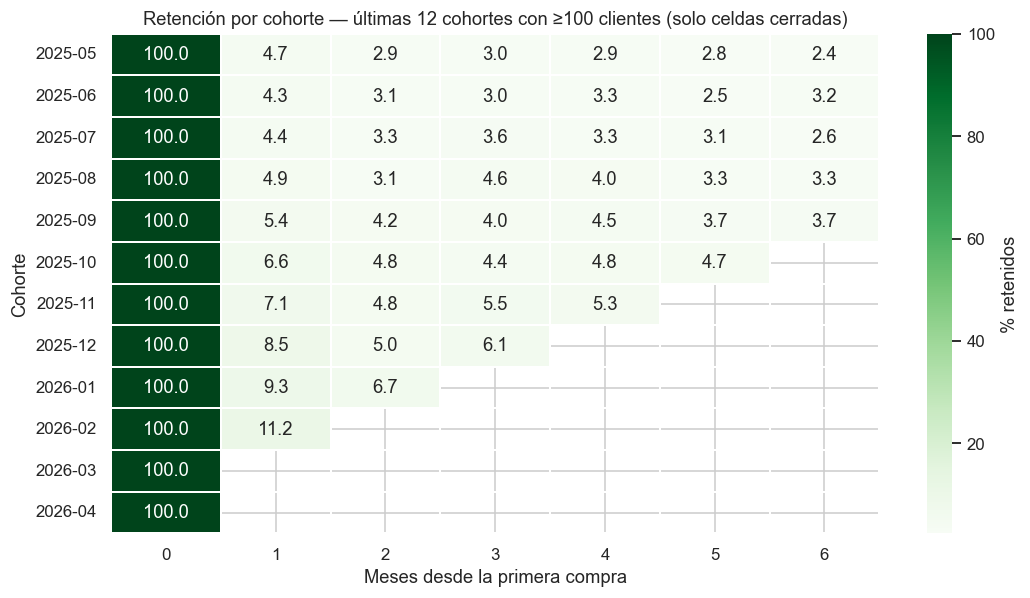

Export: dashboards/validation_retention_heatmap.png


In [9]:
fig, ax = plt.subplots(figsize=(10, 5.6))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='Greens',
            cbar_kws={'label': '% retenidos'}, linewidths=0.3, linecolor='white',
            mask=pivot.isna(), ax=ax)
ax.set_title('Retención por cohorte — últimas 12 cohortes con ≥100 clientes (solo celdas cerradas)')
ax.set_xlabel('Meses desde la primera compra')
ax.set_ylabel('Cohorte')
fig.tight_layout()
fig.savefig('../dashboards/validation_retention_heatmap.png', dpi=140, bbox_inches='tight')
plt.show()
print('Export: dashboards/validation_retention_heatmap.png')

## Cierre

Las tres piezas cumplen roles distintos y complementarios:

- El bootstrap del AOV calibra la precisión del KPI de Q1 y confirma que un intervalo de ~$5 no cambia ninguna decisión de negocio.
- El z-test sobre cohortes maduras transforma una lectura visual en un claim con soporte estadístico, y deja fuera cohortes inmaduras que serían la fuente más fácil de falso positivo.
- El heatmap reconstruido es la pieza offline que se pega en un deck cuando el dashboard no está disponible y sirve de archivo versionado en `dashboards/validation_retention_heatmap.png`.

Ninguna reemplaza a las queries. Validan que los números que el README reporta resisten una segunda mirada.